In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [14]:
samples = 1000

In [15]:
python_random = [random.randint(0, 255) for _ in range(samples)]

In [16]:
qc = QuantumCircuit(8, 8)

In [17]:
qc.h(range(8))

In [18]:
qc.measure(range(8), range(8))

In [19]:
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

In [20]:

job = simulator.run(compiled_circuit, shots=samples, memory=True)


In [21]:
results = job.result().get_memory()

In [22]:
quantum_random = [int(bits, 2) for bits in results]

In [23]:
python_mean = np.mean(python_random)
python_variance = np.var(python_random)

quantum_mean = np.mean(quantum_random)
quantum_variance = np.var(quantum_random)

print("========== Random Number Comparison ==========\n")

print("Expected Mean (0-255): 127.5\n")

print(f"Python Random")
print(f"Mean      : {python_mean:.2f}")
print(f"Variance  : {python_variance:.2f}\n")

print(f"Quantum Random")
print(f"Mean      : {quantum_mean:.2f}")
print(f"Variance  : {quantum_variance:.2f}")

========== Random Number Comparison ==========

Expected Mean (0-255): 127.5

Python Random
Mean      : 128.57
Variance  : 5573.20

Quantum Random
Mean      : 129.08
Variance  : 5434.79


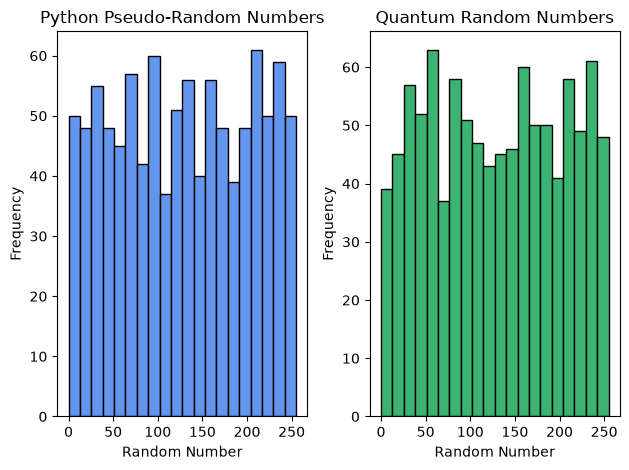

In [24]:
plt.subplot(1,2,1)
plt.hist(
    python_random,
    bins=20,
    color="cornflowerblue",
    edgecolor="black"
)
plt.title("Python Pseudo-Random Numbers")
plt.xlabel("Random Number")
plt.ylabel("Frequency")


plt.subplot(1,2,2)
plt.hist(
    quantum_random,
    bins=20,
    color="mediumseagreen",
    edgecolor="black"
)
plt.title("Quantum Random Numbers")
plt.xlabel("Random Number")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()